# 02 - Statistics
**Concept: probability and statistics.** Mean, variance, correlation, the normal distribution, standardization, train/test split.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # make `src` importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_houses, to_arrays, FEATURES, TARGET
from src.preprocessing import train_test_split, Standardizer

In [2]:
df = load_houses()
X, y = to_arrays(df)

## Mean, variance, standard deviation (by hand vs NumPy)
$\mu = \frac{1}{n}\sum x_i \qquad \sigma^2 = \frac{1}{n}\sum (x_i-\mu)^2$

In [3]:
x = df['size_m2'].to_numpy()
mean = sum(x) / len(x)
var = sum((xi - mean) ** 2 for xi in x) / len(x)
print('mean', mean, np.isclose(mean, x.mean()))
print('std ', var ** 0.5, np.isclose(var ** 0.5, x.std()))

mean 119.51419999999993 True
std  38.26040274696543 True


## Correlation
$r = \frac{\mathrm{cov}(x,y)}{\sigma_x \sigma_y}$, between -1 and +1.

In [4]:
def corr(a, b):
    cov = np.mean((a - a.mean()) * (b - b.mean()))
    return cov / (a.std() * b.std())

for i, name in enumerate(FEATURES):
    print(f'{name:10s} manual={corr(X[:, i], y):+.3f}  numpy={np.corrcoef(X[:, i], y)[0, 1]:+.3f}')

size_m2    manual=+0.891  numpy=+0.891
bedrooms   manual=+0.191  numpy=+0.191
age_years  manual=-0.246  numpy=-0.246


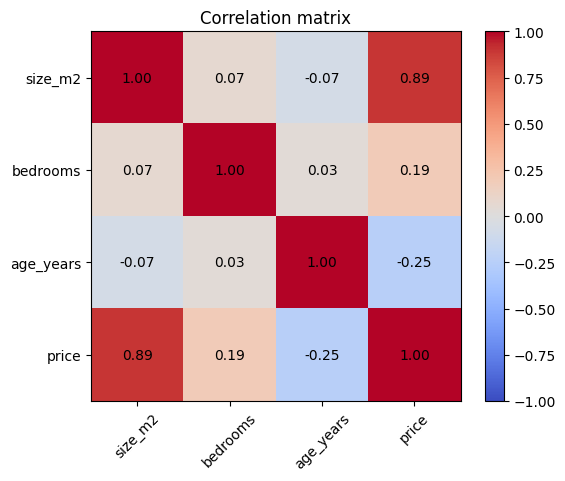

In [5]:
C = df.corr().to_numpy()
cols = list(df.columns)
plt.imshow(C, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(cols)), cols, rotation=45); plt.yticks(range(len(cols)), cols)
plt.colorbar(); plt.title('Correlation matrix')
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f'{C[i, j]:.2f}', ha='center', va='center')
plt.show()

## The normal distribution
The price noise was drawn from $\mathcal{N}(0, 15000^2)$. About 68% of values fall within 1 std, 95% within 2.

within 1 std: 0.682
within 2 std: 0.955
within 3 std: 0.998


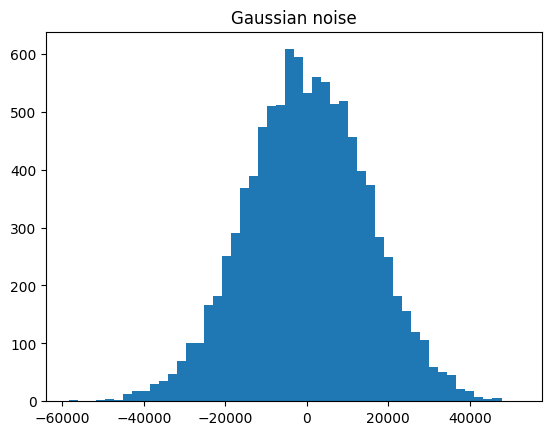

In [6]:
rng = np.random.default_rng(0)
noise = rng.normal(0, 15_000, 10_000)
for k in (1, 2, 3):
    print(f'within {k} std: {np.mean(np.abs(noise) < k * 15_000):.3f}')
plt.hist(noise, bins=50); plt.title('Gaussian noise'); plt.show()

## Standardization
$z = \frac{x-\mu}{\sigma}$ puts every feature on the same scale (mean 0, std 1). This matters for gradient descent.
Fit on the **train** set only, then apply to test, otherwise test information leaks into training.

In [7]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y)
print('train/test:', len(X_tr), len(X_te))

scaler = Standardizer().fit(X_tr)
Z_tr = scaler.transform(X_tr)
print('train mean:', Z_tr.mean(axis=0).round(6))
print('train std :', Z_tr.std(axis=0).round(6))

train/test: 400 100
train mean: [ 0. -0. -0.]
train std : [1. 1. 1.]


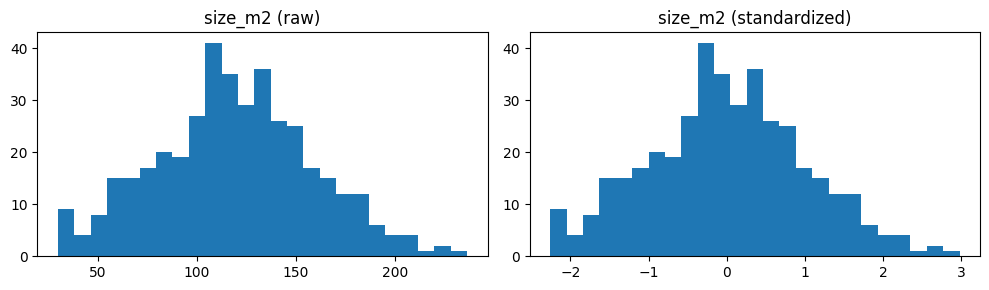

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(X_tr[:, 0], bins=25); axes[0].set_title('size_m2 (raw)')
axes[1].hist(Z_tr[:, 0], bins=25); axes[1].set_title('size_m2 (standardized)')
plt.tight_layout(); plt.show()